# validation.ipynb — evidence for the README
Validates the trained model (`model.joblib`, built by `train.py`) and the design choices in `REPORT_preprocessing.md`.

**Read this first — circularity.** There is no fraud label. Sections that report AP / precision / recall use
**rule-derived pseudo-labels**: five clusters of rows reverse-engineered from the data because they break a domain rule
by a wide margin (qty > 20, discount > 50 %, shipping > 100 or price < ½ product median, formula violation, fee rate > 0.3).
Several features encode the same rules, so those numbers are *consistency checks*, **not fraud ground truth**.
The non-circular evidence is §4 (NO_VALUE ablation), §5 (seed stability) and §6 (synthetic injection into held-out rows).

Sections: 1 setup & pseudo-labels · 2 feature-set check (11 vs 12) · 3 threshold · 4 NO_VALUE ablation · 5 seed stability ·
6 synthetic injection · 7 manual review · 8 explanations & examples · 9 comparison model (optional).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, joblib, time
from scipy.stats import spearmanr
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, roc_auc_score
from features import FULL, REDUCED_11, NO_VALUE, OrderFeatures, clean_labels, explain
from detect_anomalies import validate_orders
pd.options.display.width = 250; pd.options.display.max_columns = 40; pd.options.display.max_colwidth = 80

raw = pd.read_csv("orders-sheet.csv", dtype={"order_id": "string", "product_id": "string"})
raw.insert(0, "row_id", np.arange(len(raw)))
df, problems = validate_orders(raw)
dup = raw.drop(columns="row_id").duplicated(keep="first").to_numpy()
bundle = joblib.load("model.joblib"); pipe = bundle["pipeline"]; THR = bundle["threshold"]
score = -pipe.score_samples(df)                      # anomaly_score, higher = more anomalous
flag = score > THR
print("rows", len(df), "| invalid", len(problems), "| duplicates (train only)", dup.sum(), "| model", bundle["model_version"],
      "| features", len(bundle["feature_order"]), "| threshold", round(THR, 4), "| flagged", flag.sum(), f"({flag.mean()*100:.2f}%)")
scored = pd.read_csv("scored_orders.csv")
print("scored_orders.csv matches in-notebook scores:", np.allclose(scored.anomaly_score, score, atol=1e-6),
      "| status identical:", (scored.status.values == np.where(flag, "suspicious", "normal")).all())
one_by_one = np.array([-pipe.score_samples(df.iloc[[i]])[0] for i in range(0, len(df), 750)])
print("deployed model, 200 real rows scored one at a time == batch scores:", np.array_equal(one_by_one, score[::750]))

rows 150000 | invalid 0 | duplicates (train only) 350 | model iforest-reduced11-20261005 | features 11 | threshold 0.5031 | flagged 2702 (1.80%)
scored_orders.csv matches in-notebook scores: True | status identical: True


deployed model, 200 real rows scored one at a time == batch scores: True


## 1. Rule-derived pseudo-labels (re-derived; check that the report reproduces)
Same rules as `prep_check.ipynb`. Expected from the report: 539 / 543 / 540 / 536 / 537 = 2,695 (1.80 %), F formula-clean.

In [2]:
d = clean_labels(df)
sub = d.quantity * d.unit_price * (1 - d.discount_pct / 100)
expected = sub + d.shipping_cost + d.tax_amount
viol = ((d.order_value - expected).abs() > 0.01) & expected.notna()
pm_all = d.groupby("product_id").unit_price.transform("median")
fee_rate = d.platform_fee / sub; pr = d.unit_price / pm_all
typ = np.full(len(d), "clean", dtype=object)
typ[(d.quantity > 20).values] = "A_bulk"
typ[(d.discount_pct > 50).values] = "B_discount"
typ[((d.shipping_cost > 100) | (pr < 0.5)).values] = "C_ship_lowprice"
typ[(viol & (typ == "clean")).values] = "E_newacct_value"
typ[((fee_rate > 0.3) & (typ == "clean")).values] = "F_fee"
y = typ != "clean"; K = int(y.sum())
TYPES = ["A_bulk", "B_discount", "C_ship_lowprice", "E_newacct_value", "F_fee"]
print(pd.Series(typ).value_counts().to_dict(), "| total", K, f"({y.mean()*100:.2f}%)", "| formula violators", int(viol.sum()),
      "| F rows violating formula", int(viol[typ == "F_fee"].sum()))

{'clean': 147305, 'B_discount': 543, 'C_ship_lowprice': 540, 'A_bulk': 539, 'F_fee': 537, 'E_newacct_value': 536} | total 2695 (1.80%) | formula violators 2142 | F rows violating formula 0


## 2. Feature-set check: 11 (FULL − log_ship_ratio) vs 12 (FULL), both at n_estimators=300, max_samples=4096
Two lenses: (a) pseudo-labels (circular), (b) synthetic single-feature injection into held-out clean rows (§6 setup, non-circular). Each over 5 seeds (42–46) so differences can be compared with seed noise.

In [3]:
def fit(cols, seed=42, ms=4096, mask=None):
    mask = ~dup if mask is None else mask
    p = Pipeline([("features", OrderFeatures(tuple(cols))),
                  ("iforest", IsolationForest(n_estimators=300, max_samples=ms, random_state=seed, n_jobs=-1))]).fit(df[mask])
    return p, -p.score_samples(df[mask])                 # pipeline, training scores

def pseudo_metrics(s, thr):
    topK = np.zeros(len(s), bool); topK[np.argsort(-s)[:K]] = True; f = s > thr
    r = {"AP": average_precision_score(y, s), "P@K": topK[y].mean(), "flagged": int(f.sum()),
         "prec@thr": y[f].mean(), "recall@thr": y[f].sum() / K, "FP@thr": int((f & ~y).sum())}
    r.update({f"rec_{t[0]}": f[typ == t].mean() for t in TYPES}); return r

# --- held-out clean rows for injection: never seen in training -------------------------------
rs = np.random.RandomState(7)
pool = np.where(~y & ~dup & df.discount_pct.notna().values & df.shipping_cost.notna().values)[0]
hold = np.zeros(len(df), bool); hold[rs.choice(pool, 5600, replace=False)] = True
train_mask = ~dup & ~hold
base = df[hold].reset_index(drop=True)
def consistent(x):
    s_ = x.quantity * x.unit_price * (1 - x.discount_pct / 100)
    x["order_value"] = (s_ + x.shipping_cost + x.tax_amount).round(2); return x
nn = 600; rsi = np.random.RandomState(11)
INJ = {
 "S1 quantity x10 (fee/tax scaled, consistent)": consistent(base.iloc[:nn].assign(quantity=lambda x: x.quantity * 10, tax_amount=lambda x: x.tax_amount * 10, platform_fee=lambda x: x.platform_fee * 10)),
 "S2 unit_price x6 (fee/tax scaled, consistent)": consistent(base.iloc[nn:2*nn].assign(unit_price=lambda x: x.unit_price * 6, tax_amount=lambda x: x.tax_amount * 6, platform_fee=lambda x: x.platform_fee * 6)),
 "S3 platform_fee x8 only": base.iloc[2*nn:3*nn].assign(platform_fee=lambda x: x.platform_fee * 8),
 "S4 discount 70% (consistent)": consistent(base.iloc[3*nn:4*nn].assign(discount_pct=70.0)),
 "S5 shipping 150 (consistent)": consistent(base.iloc[4*nn:5*nn].assign(shipping_cost=150.0)),
 "S6 account_age 1-5 d only": base.iloc[5*nn:6*nn].assign(account_age_days=lambda x: rsi.randint(1, 6, len(x)).astype(float)),
 "S7 order_value x15 only": base.iloc[6*nn:7*nn].assign(order_value=lambda x: (x.order_value * 15).round(2)),
 "S8 two moderate: fee x3 + account_age 1-5 d": base.iloc[7*nn:8*nn].assign(platform_fee=lambda x: x.platform_fee * 3, account_age_days=lambda x: rsi.randint(1, 6, len(x)).astype(float)),
}
CTRL = base.iloc[8*nn:]
print("held-out clean rows", hold.sum(), "| train rows for injection models", train_mask.sum(), "| control n", len(CTRL), "| per injection n", nn)

def injection_recall(p, thr):
    r = {"control FPR": float((-p.score_samples(CTRL) > thr).mean())}
    r.update({k.split(" ")[0]: float((-p.score_samples(v) > thr).mean()) for k, v in INJ.items()}); return r

rows = []
for name, cols in [("12 FULL", FULL), ("11 REDUCED", REDUCED_11)]:
    for seed in range(42, 47):
        p, tr = fit(cols, seed); thr = np.quantile(tr, 1 - 0.018)
        s = -p.score_samples(df)
        ph, trh = fit(cols, seed, mask=train_mask); thrh = np.quantile(trh, 1 - 0.018)
        rows.append({"set": name, "seed": seed, **pseudo_metrics(s, thr), **injection_recall(ph, thrh)})
cmp = pd.DataFrame(rows)
summary = cmp.drop(columns="seed").groupby("set").agg(["mean", "std"]).T.unstack().round(3)
print(summary.to_string())

held-out clean rows 5600 | train rows for injection models 144050 | control n 800 | per injection n 600


set         11 REDUCED           12 FULL        
                  mean     std      mean     std
AP               0.973   0.008     0.959   0.007
P@K              0.907   0.016     0.872   0.011
flagged       2701.400   0.548  2702.000   0.707
prec@thr         0.905   0.016     0.870   0.011
recall@thr       0.907   0.016     0.873   0.011
FP@thr         255.800  43.350   350.200  30.351
rec_A            1.000   0.000     1.000   0.000
rec_B            1.000   0.000     1.000   0.000
rec_C            1.000   0.000     1.000   0.000
rec_E            1.000   0.000     1.000   0.000
rec_F            0.536   0.080     0.361   0.056
control FPR      0.002   0.000     0.003   0.001
S1               0.119   0.023     0.067   0.016
S2               0.126   0.016     0.079   0.036
S3               0.560   0.069     0.462   0.049
S4               0.732   0.062     0.703   0.046
S5               0.287   0.080     0.615   0.056
S6               0.140   0.011     0.114   0.030
S7               0.9

In [4]:
print("Per-seed paired difference (11 − 12), mean ± sd across 5 seeds:")
a, b = cmp[cmp.set == "11 REDUCED"].reset_index(drop=True), cmp[cmp.set == "12 FULL"].reset_index(drop=True)
num = [c for c in cmp.columns if c not in ("set", "seed")]
diff = (a[num] - b[num]); print(pd.DataFrame({"mean": diff.mean(), "sd": diff.std(), "11 better in n/5 seeds": (diff > 0).sum()}).round(3).to_string())

Per-seed paired difference (11 − 12), mean ± sd across 5 seeds:
               mean      sd  11 better in n/5 seeds
AP            0.014   0.014                       4
P@K           0.035   0.025                       4
flagged      -0.600   0.894                       0
prec@thr      0.035   0.025                       4
recall@thr    0.035   0.025                       4
FP@thr      -94.400  68.540                       1
rec_A         0.000   0.000                       0
rec_B         0.000   0.000                       0
rec_C         0.000   0.000                       0
rec_E         0.000   0.000                       0
rec_F         0.175   0.127                       4
control FPR  -0.000   0.001                       0
S1            0.052   0.031                       5
S2            0.047   0.050                       4
S3            0.098   0.040                       5
S4            0.029   0.079                       3
S5           -0.328   0.056                       0


**Reading.** On the rule-derived pseudo-labels the 11-feature set is better (AP 0.973 vs 0.959, F recall 0.54 vs 0.36,
≈ 94 fewer no-rule flags at the threshold, better in 4/5 paired seeds) — but that lens is circular.
On held-out injections the two are **tied on average** (mean recall 0.463 vs 0.457, same control FPR): 11 is better on
S1/S2/S3/S6/S7 (5/5 or 4/5 seeds) but **clearly worse on S5 "shipping 150, formula-consistent" (0.29 vs 0.62, worse in 5/5 seeds)**,
because `log_ship_ratio` is the only feature that sees shipping *out of proportion to the subtotal*.

In [5]:
m11 = cmp[cmp.set == "11 REDUCED"][num].mean(); m12 = cmp[cmp.set == "12 FULL"][num].mean()
inj_cols = [c for c in num if c.startswith("S")]
print(f"pseudo-label AP 11={m11.AP:.3f} vs 12={m12.AP:.3f} | FP@thr 11={m11['FP@thr']:.0f} vs 12={m12['FP@thr']:.0f} | F recall 11={m11.rec_F:.2f} vs 12={m12.rec_F:.2f}")
print(f"injection mean recall (S1-S8) 11={m11[inj_cols].mean():.3f} vs 12={m12[inj_cols].mean():.3f} | control FPR 11={m11['control FPR']:.4f} vs 12={m12['control FPR']:.4f}")

pseudo-label AP 11=0.973 vs 12=0.959 | FP@thr 11=256 vs 12=350 | F recall 11=0.54 vs 12=0.36
injection mean recall (S1-S8) 11=0.463 vs 12=0.457 | control FPR 11=0.0025 vs 12=0.0028


**Decision: keep the 11-feature set (as the report proposed).** Verified, not just adopted: it wins on the pseudo-labels and ties
on non-circular injections. The cost is real and goes into the README limitations: a shipping-only manipulation that keeps the
order total consistent is caught ≈ 29 % of the time instead of ≈ 62 %. The real shipping cluster (C) is unaffected (100 % both),
because those rows also break price / residual rules.

## 3. Threshold: training-score quantile vs histogram valley

In [6]:
tr_scores = score[~dup]
print(f"stored threshold (q{1-bundle['contamination']:.3f} of training scores) = {THR:.4f} -> flags {(score > THR).sum()} of all rows")
print(f"histogram valley (train.py)                 = {bundle['threshold_valley']:.4f} -> flags {(score > bundle['threshold_valley']).sum()}")
print("sklearn default (offset_ = -0.5, i.e. anomaly_score > 0.5) flags", int((score > 0.5).sum()))
band = (score > THR) & (score <= bundle["threshold_valley"])
print(f"\nrows between threshold and valley: {band.sum()} | by rule-derived type:", pd.Series(typ[band]).value_counts().to_dict())
print("flagged by type at threshold:", pd.Series(typ[flag]).value_counts().to_dict())
print("flagged by type at valley   :", pd.Series(typ[score > bundle['threshold_valley']]).value_counts().to_dict())
print("\nTrade-off (flag top k):")
for k in [1500, 2000, 2200, 2400, K, 2800, 3200, 4000]:
    sel = np.argsort(-score)[:k]
    print(f"  top {k:5d} ({k/len(score)*100:.2f}%)  score>={np.sort(score)[::-1][k-1]:.4f}  precision {y[sel].mean():.3f}  recall {y[sel].sum()/K:.3f}  F recall {(typ[sel]=='F_fee').sum()/ (typ=='F_fee').sum():.2f}")

stored threshold (q0.982 of training scores) = 0.5031 -> flags 2702 of all rows
histogram valley (train.py)                 = 0.5642 -> flags 2170
sklearn default (offset_ = -0.5, i.e. anomaly_score > 0.5) flags 2772

rows between threshold and valley: 532 | by rule-derived type: {'clean': 311, 'F_fee': 213, 'C_ship_lowprice': 7, 'E_newacct_value': 1}
flagged by type at threshold: {'B_discount': 543, 'C_ship_lowprice': 540, 'A_bulk': 539, 'E_newacct_value': 536, 'clean': 320, 'F_fee': 224}
flagged by type at valley   : {'B_discount': 543, 'A_bulk': 539, 'E_newacct_value': 535, 'C_ship_lowprice': 533, 'F_fee': 11, 'clean': 9}

Trade-off (flag top k):
  top  1500 (1.00%)  score>=0.6506  precision 1.000  recall 0.557  F recall 0.00
  top  2000 (1.33%)  score>=0.6183  precision 1.000  recall 0.742  F recall 0.00
  top  2200 (1.47%)  score>=0.5469  precision 0.993  recall 0.811  F recall 0.06
  top  2400 (1.60%)  score>=0.5183  precision 0.945  recall 0.842  F recall 0.21
  top  2695 (1.80%

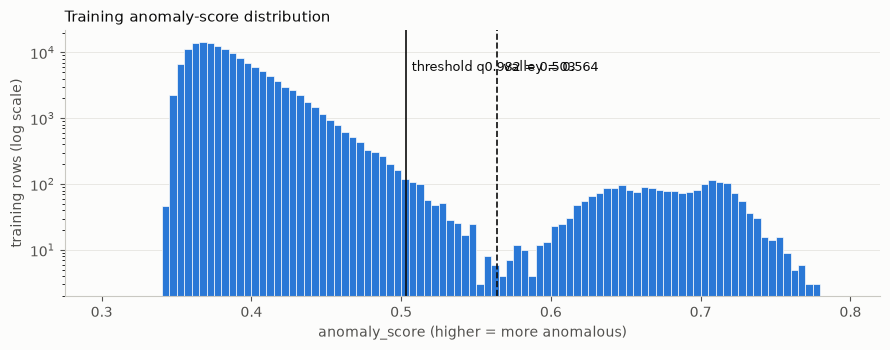

In [7]:
import matplotlib.pyplot as plt
SURFACE, INK, INK2, SERIES = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6"
fig, ax = plt.subplots(figsize=(9, 3.6), facecolor=SURFACE); ax.set_facecolor(SURFACE)
ax.hist(tr_scores, bins=np.arange(0.30, 0.80, 0.005), color=SERIES, edgecolor=SURFACE, linewidth=0.5)
ax.set_yscale("log")
for x, lab, ls in [(THR, f"threshold q0.982 = {THR:.3f}", "-"), (bundle["threshold_valley"], f"valley = {bundle['threshold_valley']:.3f}", "--")]:
    ax.axvline(x, color=INK, lw=1.2, ls=ls); ax.text(x + 0.004, ax.get_ylim()[1] * 0.35, lab, color=INK, fontsize=9, va="top")
ax.set_xlabel("anomaly_score (higher = more anomalous)", color=INK2); ax.set_ylabel("training rows (log scale)", color=INK2)
ax.set_title("Training anomaly-score distribution", color=INK, loc="left", fontsize=11)
for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
for sp in ["left", "bottom"]: ax.spines[sp].set_color("#c9c8c2")
ax.tick_params(colors=INK2); ax.grid(axis="y", color="#e6e5e0", lw=0.6); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

**Reading.** The quantile threshold (0.503) and the histogram valley (0.564) do **not** agree. The 532 rows between them are
213 fee-inflated (F) rows + 311 rows that match no rule. Valley: almost no no-rule flags (9) but F recall drops to 0.02.
Quantile: F recall 0.42 at the price of ~310 extra no-rule flags. The stored threshold stays the quantile (spec); the valley is
recorded in the bundle (`threshold_valley`) as a natural "high-confidence" band. Note the report's "sklearn default flags 4.8 %"
was measured with max_samples=256; with 4096 the default (score > 0.5) flags 2,772 (1.85 %), close to ours by coincidence.

## 4. Non-circular check 1 — NO_VALUE ablation (no `order_value`, no residual)
A model that cannot see the stated total cannot reproduce formula violations by construction. If it still recovers A/B/C, those clusters are visible from the order *inputs* alone.

In [8]:
p_nv, tr_nv = fit(NO_VALUE); s_nv = -p_nv.score_samples(df); thr_nv = np.quantile(tr_nv, 1 - 0.018)
res = pd.DataFrame({"deployed (11)": pseudo_metrics(score, THR), "NO_VALUE (9)": pseudo_metrics(s_nv, thr_nv)}).T
print(res.round(3).to_string())
f_nv = s_nv > thr_nv
print(f"\nrank corr deployed vs NO_VALUE: {spearmanr(score, s_nv)[0]:.3f} | flagged-set overlap (Jaccard): {(flag & f_nv).sum() / (flag | f_nv).sum():.3f}")
ph_nv, trh_nv = fit(NO_VALUE, mask=train_mask)
print("injection recall NO_VALUE:", {k: round(v, 2) for k, v in injection_recall(ph_nv, np.quantile(trh_nv, 1 - 0.018)).items()})

                  AP    P@K  flagged  prec@thr  recall@thr  FP@thr  rec_A  rec_B  rec_C  rec_E  rec_F
deployed (11)  0.960  0.883   2702.0     0.882       0.884   320.0    1.0  1.000    1.0  1.000  0.417
NO_VALUE (9)   0.844  0.744   2701.0     0.743       0.744   695.0    1.0  0.996    1.0  0.541  0.179

rank corr deployed vs NO_VALUE: 0.972 | flagged-set overlap (Jaccard): 0.695


injection recall NO_VALUE: {'control FPR': 0.0, 'S1': 0.15, 'S2': 0.22, 'S3': 0.17, 'S4': 0.9, 'S5': 0.76, 'S6': 0.56, 'S7': 0.01, 'S8': 0.95}


**Reading.** Without `order_value` and the residual the model still recovers A, B, C (1.00 / 1.00 / 1.00): those clusters are
visible from the stated inputs alone, so their detection is not just the residual feature echoing the pseudo-label rule.
E (new-account value inflation) drops to 0.54 and S7 (value ×15) to 0.01 — the stated total really is needed for those.
Interesting side effect: NO_VALUE does better on S5/S6/S8 (fewer features → each one gets more splits).

## 5. Non-circular check 2 — seed stability of the deployed configuration (seeds 42–46)

In [9]:
runs = {}
for seed in range(42, 47):
    p, tr = fit(REDUCED_11, seed); runs[seed] = (-p.score_samples(df), np.quantile(tr, 1 - 0.018))
s0, t0 = runs[42]; f0 = s0 > t0
print("seed 42 reproduces model.joblib exactly:", np.array_equal(s0, score))
out = []
for seed, (s, t) in runs.items():
    f = s > t
    out.append({"seed": seed, "spearman_vs_42": spearmanr(s0, s)[0], "threshold": t, "n_flagged": int(f.sum()),
                "flag_jaccard_vs_42": (f & f0).sum() / (f | f0).sum(), "AP(pseudo)": average_precision_score(y, s),
                "F recall": f[typ == "F_fee"].mean()})
st = pd.DataFrame(out).round(4); print(st.to_string(index=False))
allf = np.vstack([s > t for s, t in runs.values()])
print(f"\nrows flagged by all 5 seeds: {allf.all(0).sum()} | by >=1 seed: {allf.any(0).sum()} | unstable rows (1-4 seeds): {(allf.any(0) & ~allf.all(0)).sum()}")
print("unstable rows by type:", pd.Series(typ[allf.any(0) & ~allf.all(0)]).value_counts().to_dict())

seed 42 reproduces model.joblib exactly: True


 seed  spearman_vs_42  threshold  n_flagged  flag_jaccard_vs_42  AP(pseudo)  F recall
   42          1.0000     0.5031       2702              1.0000      0.9597    0.4171
   43          0.9860     0.5065       2701              0.8998      0.9819    0.6313
   44          0.9845     0.5039       2701              0.9269      0.9747    0.5531
   45          0.9860     0.5047       2701              0.9187      0.9764    0.5698
   46          0.9856     0.5037       2702              0.9314      0.9714    0.5065

rows flagged by all 5 seeds: 2518 | by >=1 seed: 2909 | unstable rows (1-4 seeds): 391
unstable rows by type: {'clean': 241, 'F_fee': 150}


**Reading.** Rank correlation between seeds ≈ 0.985, flagged-set Jaccard 0.90–0.93. All seed-sensitive rows are no-rule or F rows
just around the threshold; A/B/C/E are flagged by every seed. F recall varies a lot by seed (0.42–0.63) and the deployed seed 42
happens to be the weakest; I did **not** pick the seed by its pseudo-label score (that would be tuning on the pseudo-labels).

## 6. Non-circular check 3 — synthetic anomaly injection into held-out clean rows
5,600 clean, formula-consistent rows (no imputed values) were **removed before training** (setup in §2). Seven single-feature manipulations plus one two-feature combination, 600 rows each; 800 untouched rows are the control. The model (deployed config, retrained without the held-out rows, 5 seeds) uses its own training-quantile threshold. A `max|robust z| > 6` rule over the same features is shown as a reference layer.

In [10]:
from features import robust_stats
inj_runs = []
for seed in range(42, 47):
    ph, trh = fit(REDUCED_11, seed, mask=train_mask); inj_runs.append(injection_recall(ph, np.quantile(trh, 1 - 0.018)))
ir = pd.DataFrame(inj_runs)
fe_h = ph.named_steps["features"]; stats_h = robust_stats(fe_h.transform(df[train_mask]))
def maxz(x):
    X = fe_h.transform(x); return ((X - pd.Series(stats_h["median"])) / pd.Series(stats_h["scale"])).abs().max(axis=1)
zrule = {"control FPR": float((maxz(CTRL) > 6).mean())} | {k.split(" ")[0]: float((maxz(v) > 6).mean()) for k, v in INJ.items()}
p256, tr256 = fit(REDUCED_11, 42, ms=256, mask=train_mask)
r256 = injection_recall(p256, np.quantile(tr256, 1 - 0.018))
names = {"control FPR": "control (untouched)"} | {k.split(" ")[0]: k for k in INJ}
tbl = pd.DataFrame({"what": [names[c] for c in ir.columns], "IF recall mean": ir.mean().values, "IF min-max over 5 seeds":
                    [f"{ir[c].min():.2f}-{ir[c].max():.2f}" for c in ir.columns], "IF max_samples=256": [r256[c] for c in ir.columns],
                    "max|z|>6 rule": [zrule[c] for c in ir.columns]})
print(tbl.round(3).to_string(index=False))
single = [c for c in ir.columns if c.startswith("S") and c not in ("S7", "S8")]
print(f"\nmean recall on formula-consistent single-feature injections (S1-S6): {ir[single].mean().mean():.2f}"
      f" | S7 (value-only, residual sees it): {ir['S7'].mean():.2f} | S8 (two moderate deviations): {ir['S8'].mean():.2f}")

                                         what  IF recall mean IF min-max over 5 seeds  IF max_samples=256  max|z|>6 rule
                          control (untouched)           0.002               0.00-0.00               0.001          0.001
 S1 quantity x10 (fee/tax scaled, consistent)           0.119               0.10-0.15               0.042          0.427
S2 unit_price x6 (fee/tax scaled, consistent)           0.126               0.11-0.14               0.057          1.000
                      S3 platform_fee x8 only           0.560               0.47-0.64               0.112          0.813
                 S4 discount 70% (consistent)           0.732               0.63-0.79               0.563          1.000
                 S5 shipping 150 (consistent)           0.287               0.18-0.38               0.043          0.247
                    S6 account_age 1-5 d only           0.140               0.13-0.15               0.107          1.000
                      S7 order_v

**Reading — the known weakness, quantified.** Control FPR ≈ 0.2 %. A deviation in a **single** feature that leaves the order
total consistent is mostly missed: quantity ×10 → 12 %, price ×6 → 13 %, account age 1–5 d → 14 %, shipping 150 → 29 %
(mean S1–S6 = 0.33). Large deviations seen by the residual (S7) are caught (98 %), and **two moderate** deviations together (S8) reach 76 %.
max_samples=4096 vs 256 helps everywhere (S3 0.11 → 0.56, S5 0.04 → 0.29). A `max|robust z| > 6` rule catches S2/S4/S6 at 100 %
with similar control FPR on this sample, but on real data it fires on 4,365 rows (report §7.4) — a candidate second layer, not a replacement.

## 7. Manual review — top 50, 50 around the threshold, 50 random normal

In [11]:
fe = pipe.named_steps["features"]; X = fe.transform(df)
reasons = explain(X, bundle["explain_stats"], top=3)
pm = fe.product_median_price(clean_labels(df))
view = pd.DataFrame({"row_id": df.row_id, "order_id": df.order_id, "score": score.round(4), "rule_type": typ,
    "qty": df.quantity.astype(int), "price": df.unit_price, "prod_med": pm.round(2), "disc": df.discount_pct, "ship": df.shipping_cost,
    "tax": df.tax_amount, "fee": df.platform_fee, "value": df.order_value, "formula": expected.round(2), "acct_d": df.account_age_days.astype(int),
    "top3 (robust z)": [", ".join(f"{f}={z:+.1f}" for f, z in r) for r in reasons]})
order = np.argsort(-score)
top50 = view.iloc[order[:50]]
print("TOP 50 — rule types:", top50.rule_type.value_counts().to_dict()); print(top50.to_string(index=False))

TOP 50 — rule types: {'C_ship_lowprice': 33, 'A_bulk': 16, 'B_discount': 1}
 row_id   order_id  score       rule_type  qty   price  prod_med  disc   ship    tax    fee     value   formula  acct_d                                                       top3 (robust z)
 124558 ORD0040723 0.7789 C_ship_lowprice    1    1.31     88.95  50.0 710.69   9.46   7.41     62.42    720.80    2739  log_value_ratio=-244.6, log1p_tax_rate=+38.8, price_vs_product=-29.3
  18976 ORD0088054 0.7770 C_ship_lowprice    3    2.74    347.93  10.0 706.51 122.04 126.96   1086.43    835.95      44   log1p_tax_rate=+40.6, price_vs_product=-33.7, log_value_ratio=+26.2
  18202 ORD0086488 0.7755 C_ship_lowprice    6    2.17    347.93  15.0 883.64 135.41 296.96   2219.82   1030.12     427   log_value_ratio=+76.8, log1p_tax_rate=+36.5, price_vs_product=-35.3
 110845 ORD0004365 0.7744 C_ship_lowprice   10    1.96    167.66  40.0 350.26 133.51 103.24   1192.36    495.53    2863   log_value_ratio=+87.8, log1p_tax_rate=+35.

In [12]:
pos = int(np.searchsorted(-score[order], -THR))      # first index at/below threshold in descending order
near = view.iloc[order[pos - 25: pos + 25]]
print(f"50 AROUND THRESHOLD ({THR:.4f}; 25 above, 25 below) — rule types:", near.rule_type.value_counts().to_dict())
print(near.to_string(index=False))

50 AROUND THRESHOLD (0.5031; 25 above, 25 below) — rule types: {'clean': 36, 'F_fee': 14}
 row_id   order_id  score rule_type  qty  price  prod_med  disc  ship    tax    fee   value  formula  acct_d                                                  top3 (robust z)
 133756 ORD0048780 0.5039     F_fee    1  44.27     41.02  10.0  0.07   4.02  17.06   43.93    43.93     137      log_fee_rate=+4.4, log_fee_to_value=+4.4, log_shipping=-3.5
  36471 ORD0090970 0.5038     F_fee    1  10.31     10.65  10.0  8.55   0.83  12.56   18.66    18.66    2406    log_fee_rate=+8.3, log_fee_to_value=+6.0, log_unit_price=-1.2
 108483 ORD0007470 0.5038     clean    1   2.88      3.00  40.0  3.58   0.13   0.16    5.44     5.44     222    discount_pct=+3.6, log_fee_to_value=-3.1, log_unit_price=-2.6
  62373 ORD0078047 0.5038     clean    1   6.43      7.42  10.0  5.22   0.33   0.51   11.34    11.34       2    log_acct_age=-7.6, log_fee_to_value=-1.9, log_unit_price=-1.7
 122867 ORD0045592 0.5038     clean    2

In [13]:
rnd = view[~flag].sample(50, random_state=0)
print("50 RANDOM NORMAL — rule types:", rnd.rule_type.value_counts().to_dict(), "| score range", rnd.score.min(), "-", rnd.score.max())
print(rnd.to_string(index=False))

50 RANDOM NORMAL — rule types: {'clean': 50} | score range 0.3458 - 0.4853
 row_id   order_id  score rule_type  qty  price  prod_med  disc  ship   tax   fee   value  formula  acct_d                                                    top3 (robust z)
  77130 ORD0015624 0.3751     clean    1  18.23     22.05   0.0   NaN  0.08  1.52   28.48      NaN     929  log_fee_to_value=-1.4, log1p_tax_rate=-1.3, price_vs_product=-1.3
  12269 ORD0042050 0.3602     clean    1  12.96     14.84   0.0  6.21  1.79  1.26   20.96    20.96     791 log_fee_to_value=-1.1, price_vs_product=-0.9, log_order_value=-0.9
  40746 ORD0089444 0.3906     clean    1  14.84     13.71   0.0  0.00  1.02  1.54   15.86    15.86     714         log_shipping=-3.6, log_order_value=-1.2, log_acct_age=-0.9
 121440 ORD0032782 0.3458     clean    1  41.14     41.72   0.0  4.52  4.49  5.33   50.15    50.15    1989        log_fee_to_value=+0.6, log_shipping=-0.6, log_fee_rate=+0.4
  66289 ORD0039310 0.3950     clean    2   6.55      7.

### 7b. Flagged rows that match no rule (the false-positive candidates)

In [14]:
fp = flag & ~y
v = view[fp]; sub_c = (df.quantity * df.unit_price * (1 - df.discount_pct.fillna(0) / 100))
print(f"flagged {flag.sum()} | rule-derived types {(flag & y).sum()} | match no rule {fp.sum()}")
print("top-1 explaining feature among no-rule flagged:", pd.Series([r[0][0] for r, f in zip(reasons, fp) if f]).value_counts().to_dict())
cmpfp = pd.DataFrame({"no-rule flagged": [sub_c[fp].median(), df.order_value[fp].median(), (df.quantity[fp] == 1).mean(), df.discount_pct[fp].median(),
                                          fee_rate[fp].median(), (df.account_age_days[fp] <= 30).mean(), df.discount_pct[fp].isna().mean() + df.shipping_cost[fp].isna().mean()],
                      "all clean rows": [sub_c[~y].median(), df.order_value[~y].median(), (df.quantity[~y] == 1).mean(), df.discount_pct[~y].median(),
                                         fee_rate[~y].median(), (df.account_age_days[~y] <= 30).mean(), df.discount_pct[~y].isna().mean() + df.shipping_cost[~y].isna().mean()]},
                     index=["median subtotal", "median order_value", "share qty=1", "median discount", "median fee_rate", "share acct<=30d", "share imputed"])
print(cmpfp.round(3).to_string())
for cut in [5, 10, 20]:
    m = sub_c < cut
    print(f"subtotal < {cut:>2}: {m.sum():6d} rows ({m.mean()*100:.1f}% of data) | flag rate among no-rule rows {flag[m & ~y].mean()*100:.2f}% vs {flag[~m & ~y].mean()*100:.3f}% otherwise"
          f" | share of no-rule flags {(fp & m).sum() / fp.sum():.2f}")
print(f"fee_rate of no-rule flagged: min {fee_rate[fp].min():.3f} max {fee_rate[fp].max():.3f} (clean range 0.069-0.170)")
big = (df.order_value > df.order_value[~y].quantile(0.99)).values & ~y
print(f"large clean orders (order_value > clean p99 = {df.order_value[~y].quantile(0.99):.0f}): {big.sum()} rows, flagged {flag[big].sum()} ({flag[big].mean()*100:.1f}%)")
newacct = (df.account_age_days <= 7).values & ~y
print(f"clean orders from accounts <= 7 days: {newacct.sum()} rows, flagged {flag[newacct].sum()} ({flag[newacct].mean()*100:.1f}%)")

flagged 2702 | rule-derived types 2382 | match no rule 320
top-1 explaining feature among no-rule flagged: {'log_acct_age': 97, 'discount_pct': 88, 'log_quantity': 53, 'log_shipping': 50, 'log_fee_to_value': 23, 'log_order_value': 6, 'log_fee_rate': 2, 'log_unit_price': 1}
                    no-rule flagged  all clean rows
median subtotal               6.700          40.060
median order_value           13.700          50.790
share qty=1                   0.491           0.573
median discount              40.000           5.000
median fee_rate               0.106           0.115
share acct<=30d               0.278           0.010
share imputed                 0.022           0.010
subtotal <  5:   4258 rows (2.8% of data) | flag rate among no-rule rows 3.74% vs 0.124% otherwise | share of no-rule flags 0.44
subtotal < 10:  15732 rows (10.5% of data) | flag rate among no-rule rows 1.20% vs 0.107% otherwise | share of no-rule flags 0.56
subtotal < 20:  39270 rows (26.2% of data) | flag r

In [15]:
pd.DataFrame({"row_id": view.row_id, "order_id": view.order_id, "anomaly_score": view.score, "rule_type": view.rule_type,
              "reason_1": [f"{r[0][0]} (z={r[0][1]:+.1f})" for r in reasons], "reason_2": [f"{r[1][0]} (z={r[1][1]:+.1f})" for r in reasons],
              "reason_3": [f"{r[2][0]} (z={r[2][1]:+.1f})" for r in reasons]})[flag].sort_values("anomaly_score", ascending=False) \
  .to_csv("flagged_explanations.csv", index=False)
print("wrote flagged_explanations.csv:", flag.sum(), "rows")

wrote flagged_explanations.csv: 2702 rows


**Manual-review reading.**
* **Top 50:** all rule-derived (33 C shipping/low-price, 16 A bulk, 1 B). Explanations match the rule each row breaks.
* **Around the threshold:** 14 F (fee-inflated, explained by `log_fee_rate` z ≈ +6…+8) and 36 rows that match no rule.
* **50 random normal:** all clean; max |z| mostly < 4, scores 0.35–0.49.
* **Suspicious-but-legitimate pattern (confirmed from the report):** the 320 flagged rows that match no rule are dominated by
  **very small, heavily discounted orders** (median subtotal 6.70 vs 40.06; median discount 40 % vs 5 %; 44 % have subtotal < 5 —
  for no-rule rows with subtotal < 5 the flag rate is 3.7 % vs 0.12 % otherwise) and **brand-new accounts with ordinary orders**
  (28 % from accounts ≤ 30 d vs 1 %; `log_acct_age` is the top reason for 97 of them). Their fee rates are normal (0.069–0.160).
  A smaller group are large-but-consistent orders (qty 8–10, values 1–4k). They are statistically rare but break no rule — expect
  reviewers to clear them; they make up ~12 % of flags.

## 8. Explained example orders
Robust z = (feature − training median) / max(IQR/1.349, 0.01), training = deduplicated rows (stored in the bundle). `log_value_ratio` has IQR 0 (clean rows are exactly on the formula) so its z is floor-dominated; it is translated to "order_value = ×N the formula" in words.

In [16]:
def pick_rep(t):
    """Representative flagged member of a rule type: the median-scoring one (not the most extreme)."""
    idx = np.where(flag & (typ == t))[0]; return idx[np.argsort(score[idx])[len(idx) // 2]]
ex = {t: pick_rep(t) for t in TYPES}
ex["near threshold (just above)"] = order[pos - 1]
big_normal = np.where(~flag & ~y)[0]; ex["extreme but normal (largest clean order_value)"] = big_normal[np.argmax(df.order_value.values[big_normal])]
def describe(i):
    r = df.iloc[i]; e = expected.iloc[i]
    ratio = r.order_value / e if pd.notna(e) else float("nan")
    return (f"row_id {int(r.row_id)} / {r.order_id} | score {score[i]:.3f} ({'suspicious' if flag[i] else 'normal'}) | qty {int(r.quantity)} @ {r.unit_price}"
            f" (product median {pm.iloc[i]:.2f}) | disc {r.discount_pct} | ship {r.shipping_cost} | tax {r.tax_amount} | fee {r.platform_fee}"
            f" (fee/subtotal {fee_rate.iloc[i]:.3f}) | value {r.order_value} vs formula {e:.2f} (x{ratio:.2f}) | account {int(r.account_age_days)} d")
for k, i in ex.items():
    print(f"[{k}]\n  {describe(i)}\n  top-3 robust z: {reasons[i]}\n")

[A_bulk]
  row_id 61596 / ORD0068411 | score 0.713 (suspicious) | qty 77 @ 1642.58 (product median 18.64) | disc 0.0 | ship 6.41 | tax 2.66 | fee 1.12 (fee/subtotal 0.000) | value 124546.92 vs formula 126487.73 (x0.98) | account 1915 d
  top-3 robust z: [('price_vs_product', 31.1), ('log_fee_to_value', -26.7), ('log_fee_rate', -23.8)]

[B_discount]
  row_id 20465 / ORD0072849 | score 0.673 (suspicious) | qty 2 @ 9.21 (product median 10.73) | disc 74.0 | ship 8.95 | tax 1.36 | fee 2.34 (fee/subtotal 0.489) | value 4466.15 vs formula 15.10 (x295.79) | account 1927 d
  top-3 robust z: [('log_value_ratio', 569.0), ('log_fee_to_value', -14.9), ('discount_pct', 6.7)]

[C_ship_lowprice]
  row_id 81546 / ORD0013345 | score 0.670 (suspicious) | qty 2 @ 2.98 (product median 23.08) | disc 0.0 | ship 866.66 | tax 3.08 | fee 2.97 (fee/subtotal 0.498) | value 50.28 vs formula 875.70 (x0.06) | account 1058 d
  top-3 robust z: [('log_value_ratio', -285.7), ('price_vs_product', -14.2), ('log_shipping',

## 9. Optional comparison model — Elliptic Envelope on robust-scaled reduced (non-collinear) features

In [17]:
from sklearn.preprocessing import RobustScaler
from sklearn.covariance import EllipticEnvelope
LEAN = ["log_quantity", "log_unit_price", "discount_pct", "log_shipping", "log1p_tax_rate", "log_fee_rate", "price_vs_product", "log_value_ratio", "log_acct_age"]
feL = OrderFeatures(tuple(LEAN)).fit(df[~dup]); XL = feL.transform(df)
rsc = RobustScaler().fit(XL[~dup]); Z = rsc.transform(XL)
idx = np.random.RandomState(0).choice(np.where(~dup)[0], 30000, replace=False)
t0 = time.time(); ee = EllipticEnvelope(contamination=0.018, support_fraction=0.9, random_state=0).fit(Z[idx])
print(f"fit {time.time()-t0:.1f}s | condition number of robust covariance: {np.linalg.cond(ee.covariance_):.1f}")
s_ee = -ee.score_samples(Z); thr_ee = np.quantile(s_ee[~dup], 1 - 0.018); f_ee = s_ee > thr_ee
print(pd.DataFrame({"IsolationForest (deployed)": pseudo_metrics(score, THR), "EllipticEnvelope": pseudo_metrics(s_ee, thr_ee)}).T.round(3).to_string())
print(f"flagged-set Jaccard IF vs EE: {(flag & f_ee).sum() / (flag | f_ee).sum():.3f} | flagged by IF only {(flag & ~f_ee).sum()} | EE only {(f_ee & ~flag).sum()}")
print("IF-only by type:", pd.Series(typ[flag & ~f_ee]).value_counts().to_dict(), "| EE-only by type:", pd.Series(typ[f_ee & ~flag]).value_counts().to_dict())
rscH = RobustScaler().fit(feL.transform(df[train_mask]))
idxH = np.random.RandomState(0).choice(np.where(train_mask)[0], 30000, replace=False)
eeH = EllipticEnvelope(contamination=0.018, support_fraction=0.9, random_state=0).fit(rscH.transform(feL.transform(df.iloc[idxH])))
thrH = np.quantile(-eeH.score_samples(rscH.transform(feL.transform(df[train_mask]))), 1 - 0.018)
eeinj = {"control FPR": float((-eeH.score_samples(rscH.transform(feL.transform(CTRL))) > thrH).mean())}
eeinj |= {k.split(" ")[0]: float((-eeH.score_samples(rscH.transform(feL.transform(v))) > thrH).mean()) for k, v in INJ.items()}
print("EE injection recall:", {k: round(v, 2) for k, v in eeinj.items()})

fit 3.4s | condition number of robust covariance: 729564916.5
                               AP    P@K  flagged  prec@thr  recall@thr  FP@thr  rec_A  rec_B  rec_C  rec_E  rec_F
IsolationForest (deployed)  0.960  0.883   2702.0     0.882       0.884   320.0    1.0    1.0  1.000    1.0  0.417
EllipticEnvelope            0.909  0.806   2702.0     0.804       0.806   530.0    1.0    1.0  0.998    1.0  0.028
flagged-set Jaccard IF vs EE: 0.718 | flagged by IF only 443 | EE only 443
IF-only by type: {'clean': 233, 'F_fee': 209, 'C_ship_lowprice': 1} | EE-only by type: {'clean': 443}


EE injection recall: {'control FPR': 0.01, 'S1': 0.0, 'S2': 0.97, 'S3': 0.01, 'S4': 0.04, 'S5': 0.0, 'S6': 0.0, 'S7': 1.0, 'S8': 0.01}
